In [55]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATTERN = "hashjoin_*.csv"
RESULTS_CANDIDATES = [
    Path("results"),
    Path("src/results"),
    Path("../results"),
]

RESULTS_DIR = None
csv_files = []
for candidate_dir in RESULTS_CANDIDATES:
    candidate_files = sorted(candidate_dir.glob(CSV_PATTERN))
    if candidate_files:
        RESULTS_DIR = candidate_dir
        csv_files = candidate_files
        break

if not csv_files or RESULTS_DIR is None:
    searched = ", ".join(str(p) for p in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"No CSV files found with pattern {CSV_PATTERN} in: {searched}")

frames = []
for csv_path in csv_files:
    current_df = pd.read_csv(csv_path)
    current_df["exec_type"] = csv_path.stem.replace("hashjoin_", "", 1)
    current_df["source_file"] = csv_path.name
    frames.append(current_df)

df = pd.concat(frames, ignore_index=True, sort=False)

numeric_columns = [
    "checksum1",
    "checksum2",
    "join_count",
    "join_threads",
    "join_throughput",
    "join_time",
    "max_key",
    "nr",
    "ns",
    "partition_threads",
    "partition_throughput",
    "partition_time",
    "time_sec",
    "total_throughput",
]
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

fallback_total_throughput = (df["nr"] + df["ns"]) / df["time_sec"].where(df["time_sec"] > 0)
if "total_throughput" not in df.columns:
    df["total_throughput"] = fallback_total_throughput
else:
    df["total_throughput"] = df["total_throughput"].fillna(fallback_total_throughput)

exec_type_names = sorted(df["exec_type"].dropna().unique())
exec_type_palette = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]
exec_type_colors = {
    exec_type: exec_type_palette[idx % len(exec_type_palette)]
    for idx, exec_type in enumerate(exec_type_names)
}


def resolve_img_dir():
    candidates = [
        Path("src/img"),
        Path("img"),
        Path("../src/img"),
        Path("../img"),
    ]
    for candidate in candidates:
        if candidate.parent.exists() or candidate.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    fallback = Path("img")
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


IMG_DIR = resolve_img_dir()
PLOT_SAVE_COUNTER = 0


def slugify(value):
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    if not cleaned:
        return "plot"
    return cleaned[:180]


def save_figure(fig, name_prefix):
    global PLOT_SAVE_COUNTER
    PLOT_SAVE_COUNTER += 1
    filename = f"{PLOT_SAVE_COUNTER:03d}_{slugify(name_prefix)}.png"
    output_path = IMG_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"[saved] {output_path}")


def show_and_save(fig, name_prefix):
    save_figure(fig, name_prefix)
    plt.show()
    plt.close(fig)


print(f"[Loaded {df.shape[0]} runs from {RESULTS_DIR}]\n")
print("Files:")
for csv_path in csv_files:
    print(f"  - {csv_path.name}")

print("\nDistinct values:")
print(f"  exec_type: {exec_type_names}")
print(f"  max_key: {sorted(df['max_key'].dropna().unique())}")
print(f"  partition_threads: {sorted(df['partition_threads'].dropna().unique())}")
print(f"  join_threads: {sorted(df['join_threads'].dropna().unique())}")
print(f"  image_output_dir: {IMG_DIR}")


def _as_2d_axes(axes, nrows, ncols):
    if nrows == 1 and ncols == 1:
        return [[axes]]
    if nrows == 1:
        return [list(axes)]
    if ncols == 1:
        return [[ax] for ax in axes]
    return axes


def plot_thread_matrix(metric_df, metric_col, y_label, title_prefix, global_ymax=None):
    required_cols = {
        "nr",
        "ns",
        "max_key",
        "partition_threads",
        "join_threads",
        "exec_type",
        metric_col,
    }
    missing_cols = sorted(required_cols - set(metric_df.columns))
    if missing_cols:
        print(f"Skipping {metric_col}: missing columns {missing_cols}")
        return

    for (fixed_nr, fixed_ns, fixed_max_key), subdf in metric_df.groupby(["nr", "ns", "max_key"]):
        part_values = sorted(subdf["partition_threads"].dropna().unique())
        join_values = sorted(subdf["join_threads"].dropna().unique())

        seq_ref = subdf[subdf["exec_type"] == "seq"]
        seq_value = (
            float(seq_ref[metric_col].mean())
            if not seq_ref.empty and pd.notna(seq_ref[metric_col].mean())
            else float("nan")
        )

        if pd.notna(seq_value):
            if 1 not in part_values:
                part_values = [1] + part_values
            if 1 not in join_values:
                join_values = [1] + join_values

        other_exec_types = sorted([e for e in subdf["exec_type"].dropna().unique() if e != "seq"])
        exec_types = (["seq"] if pd.notna(seq_value) else []) + other_exec_types

        if not exec_types or not part_values or not join_values:
            continue

        value_lookup = (
            subdf.dropna(subset=["partition_threads", "join_threads"])
            .set_index(["exec_type", "partition_threads", "join_threads"])[metric_col]
            .to_dict()
        )

        nrows = len(join_values)
        ncols = len(part_values)
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(max(3.2 * ncols, 8), max(2.6 * nrows, 6)),
            sharey=True,
        )
        axes_2d = _as_2d_axes(axes, nrows, ncols)

        for r, join_threads in enumerate(join_values):
            for c, part_threads in enumerate(part_values):
                ax = axes_2d[r][c]

                heights = []
                for exec_type in exec_types:
                    if exec_type == "seq":
                        value = seq_value if (part_threads == 1 and join_threads == 1) else float("nan")
                    else:
                        value = value_lookup.get((exec_type, part_threads, join_threads), float("nan"))
                    heights.append(value)

                x_positions = list(range(len(exec_types)))
                colors = [exec_type_colors.get(exec_type, "tab:gray") for exec_type in exec_types]
                ax.bar(x_positions, heights, color=colors)

                if pd.notna(global_ymax) and global_ymax > 0:
                    ax.set_ylim(0, global_ymax * 1.05)

                ax.set_xticks(x_positions)
                ax.set_xticklabels(exec_types, rotation=45, ha="right", fontsize=8)

                if r == 0:
                    ax.set_title(f"partition_threads={int(part_threads)}", fontsize=9)
                if c == 0:
                    ax.set_ylabel(f"join_threads={int(join_threads)}\n{y_label}", fontsize=8)

                ax.grid(axis="y", alpha=0.25)

        fig.suptitle(
            f"{title_prefix} matrix (nr={int(fixed_nr)}, ns={int(fixed_ns)}, max_key={int(fixed_max_key)})",
            y=1.02,
        )
        fig.tight_layout()
        show_and_save(
            fig,
            f"{title_prefix}_matrix_nr{int(fixed_nr)}_ns{int(fixed_ns)}_maxkey{int(fixed_max_key)}",
        )


[Loaded 505 runs from results]

Files:
  - hashjoin_par_p.csv
  - hashjoin_par_pj.csv
  - hashjoin_par_pj_wb.csv
  - hashjoin_par_pj_wb_map.csv
  - hashjoin_seq.csv

Distinct values:
  exec_type: ['par_p', 'par_pj', 'par_pj_wb', 'par_pj_wb_map', 'seq']
  max_key: [1000000]
  partition_threads: [1, 4, 8, 16, 32, 64]
  join_threads: [1, 4, 8, 16, 32, 64]
  image_output_dir: img


# Checksum validation

In [56]:
checksum_group_cols = ["nr", "ns", "max_key"]
summary_rows = []

for (nr, ns, max_key), subdf in df.groupby(checksum_group_cols):
    checksum_pairs = subdf[["checksum1", "checksum2"]].drop_duplicates()
    summary_rows.append({
        "nr": nr,
        "ns": ns,
        "max_key": max_key,
        "n_distinct_checksum_pairs": len(checksum_pairs),
        "is_valid": len(checksum_pairs) == 1,
        "exec_types": ", ".join(sorted(subdf["exec_type"].dropna().unique())),
    })

checksum_validation_df = (
    pd.DataFrame(summary_rows)
    .sort_values(checksum_group_cols)
    .reset_index(drop=True)
)

valid_groups = int(checksum_validation_df["is_valid"].sum()) if not checksum_validation_df.empty else 0
print(f"[OK groups: {valid_groups}/{len(checksum_validation_df)}]")
checksum_validation_df


[OK groups: 1/1]


,nr,ns,max_key,n_distinct_checksum_pairs,is_valid,exec_types
0,50000000,50000000,1000000,1,True,"par_p, par_pj, par_pj_wb, par_pj_wb_map, seq"


# Averaging

In [57]:
group_columns = [
    "exec_type",
    "nr",
    "ns",
    "max_key",
    "partition_threads",
    "join_threads",
    "checksum1",
    "checksum2",
    "join_count",
]
avg_candidates = [
    "partition_time",
    "join_time",
    "time_sec",
    "partition_throughput",
    "join_throughput",
    "total_throughput",
]
avg_columns = [col for col in avg_candidates if col in df.columns]

stable_avg_df = (
    df.groupby(group_columns, as_index=False)
    .agg({col: "mean" for col in avg_columns})
    .sort_values(group_columns)
    .reset_index(drop=True)
)

stable_avg_df.head(10)


,exec_type,nr,ns,max_key,partition_threads,join_threads,checksum1,checksum2,join_count,partition_time,join_time,time_sec,partition_throughput,join_throughput,total_throughput
0,par_p,50000000,50000000,1000000,4,4,6185417096973469475,16931092769743058723,2499986166,0.918371,2.296605,3.217214,1.088893e+08,4.391655e+07,3.121363e+07
1,par_p,50000000,50000000,1000000,4,8,6185417096973469475,16931092769743058723,2499986166,0.928452,2.215488,3.146184,1.077168e+08,4.550518e+07,3.191238e+07
2,par_p,50000000,50000000,1000000,4,16,6185417096973469475,16931092769743058723,2499986166,0.920281,2.236525,3.159045,1.086645e+08,4.510712e+07,3.179849e+07
3,par_p,50000000,50000000,1000000,4,32,6185417096973469475,16931092769743058723,2499986166,0.925180,2.300421,3.227885,1.080976e+08,4.381352e+07,3.110676e+07
4,par_p,50000000,50000000,1000000,4,64,6185417096973469475,16931092769743058723,2499986166,0.918467,2.219970,3.140709,1.088798e+08,4.538073e+07,3.196101e+07
5,par_p,50000000,50000000,1000000,8,4,6185417096973469475,16931092769743058723,2499986166,0.600664,2.226311,2.829213,1.664839e+08,4.520071e+07,3.548525e+07
6,par_p,50000000,50000000,1000000,8,8,6185417096973469475,16931092769743058723,2499986166,0.599982,2.199622,2.802032,1.666785e+08,4.580279e+07,3.585358e+07
7,par_p,50000000,50000000,1000000,8,16,6185417096973469475,16931092769743058723,2499986166,0.598968,2.195755,2.797002,1.669571e+08,4.592830e+07,3.594132e+07
8,par_p,50000000,50000000,1000000,8,32,6185417096973469475,16931092769743058723,2499986166,0.599751,2.363519,2.965585,1.667364e+08,4.250353e+07,3.381657e+07
9,par_p,50000000,50000000,1000000,8,64,6185417096973469475,16931092769743058723,2499986166,0.597889,2.275230,2.875373,1.672577e+08,4.429260e+07,3.494304e+07


# Partition time

[saved] img/001_partition_time_matrix_nr50000000_ns50000000_maxkey1000000.png


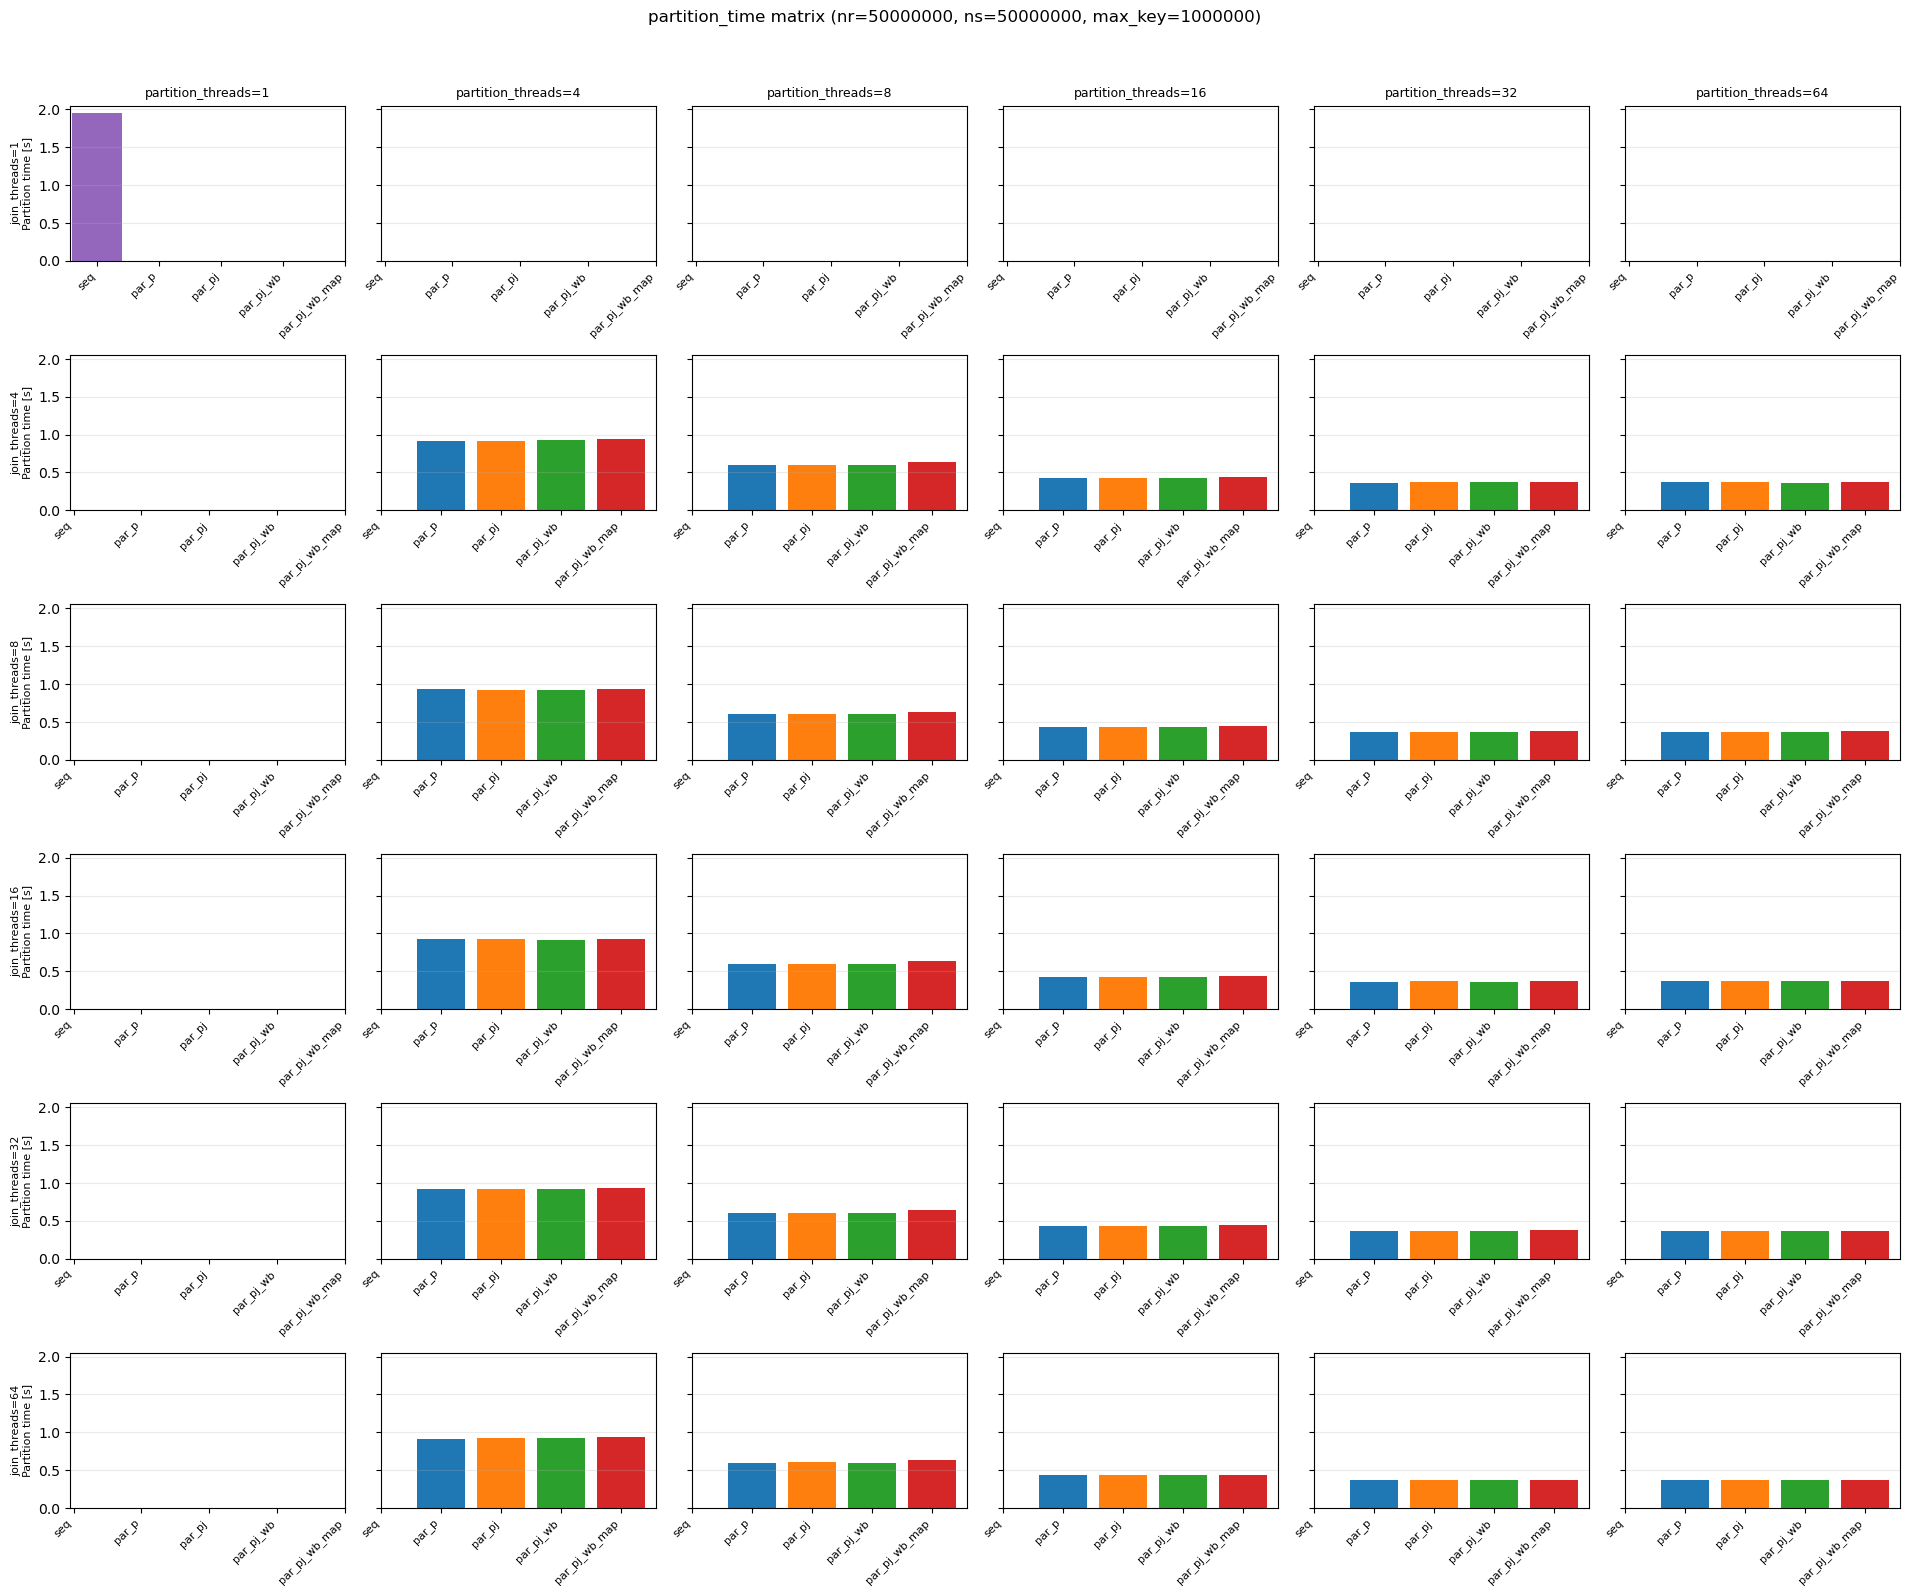

In [58]:
global_partition_time_ymax = stable_avg_df["partition_time"].max()
plot_thread_matrix(
    stable_avg_df,
    metric_col="partition_time",
    y_label="Partition time [s]",
    title_prefix="partition_time",
    global_ymax=global_partition_time_ymax,
)


# Partition time standard deviation

[saved] img/002_std_partition_time_by_max_key.png


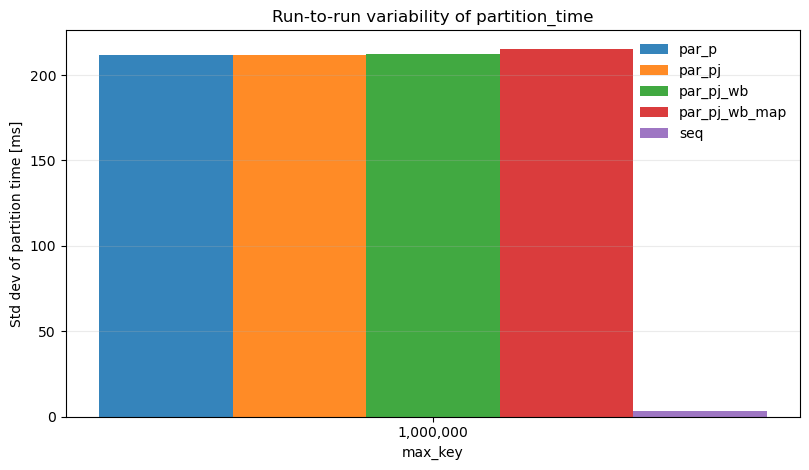

,max_key,exec_type,std_partition_time,std_ms
0,1000000,par_p,0.211745,211.744840
1,1000000,par_pj,0.211577,211.577412
2,1000000,par_pj_wb,0.212199,212.199406
3,1000000,par_pj_wb_map,0.215402,215.402458
4,1000000,seq,0.003029,3.028869


In [59]:
std_df = (
    df.groupby(["max_key", "exec_type"], as_index=False)
    .agg(std_partition_time=("partition_time", "std"))
)
std_df["std_ms"] = std_df["std_partition_time"] * 1e3

max_key_values = sorted(std_df["max_key"].dropna().unique())
exec_types = sorted(std_df["exec_type"].dropna().unique())

x_positions = list(range(len(max_key_values)))
bar_width = 0.8 / len(exec_types) if exec_types else 0.8

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for idx, exec_type in enumerate(exec_types):
    heights = []
    for max_key in max_key_values:
        sub = std_df[(std_df["max_key"] == max_key) & (std_df["exec_type"] == exec_type)]
        heights.append(float(sub["std_ms"].iloc[0]) if not sub.empty else float("nan"))

    offsets = [
        x + (idx - (len(exec_types) - 1) / 2) * bar_width
        for x in x_positions
    ]
    ax.bar(
        offsets,
        heights,
        width=bar_width,
        label=exec_type,
        color=exec_type_colors.get(exec_type, "tab:gray"),
        alpha=0.9,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels([f"{int(v):,}" for v in max_key_values])
ax.set_xlabel("max_key")
ax.set_ylabel("Std dev of partition time [ms]")
ax.set_title("Run-to-run variability of partition_time")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
show_and_save(fig, "std_partition_time_by_max_key")

std_df.sort_values(["max_key", "exec_type"]).reset_index(drop=True)


# Join time

[saved] img/003_join_time_matrix_nr50000000_ns50000000_maxkey1000000.png


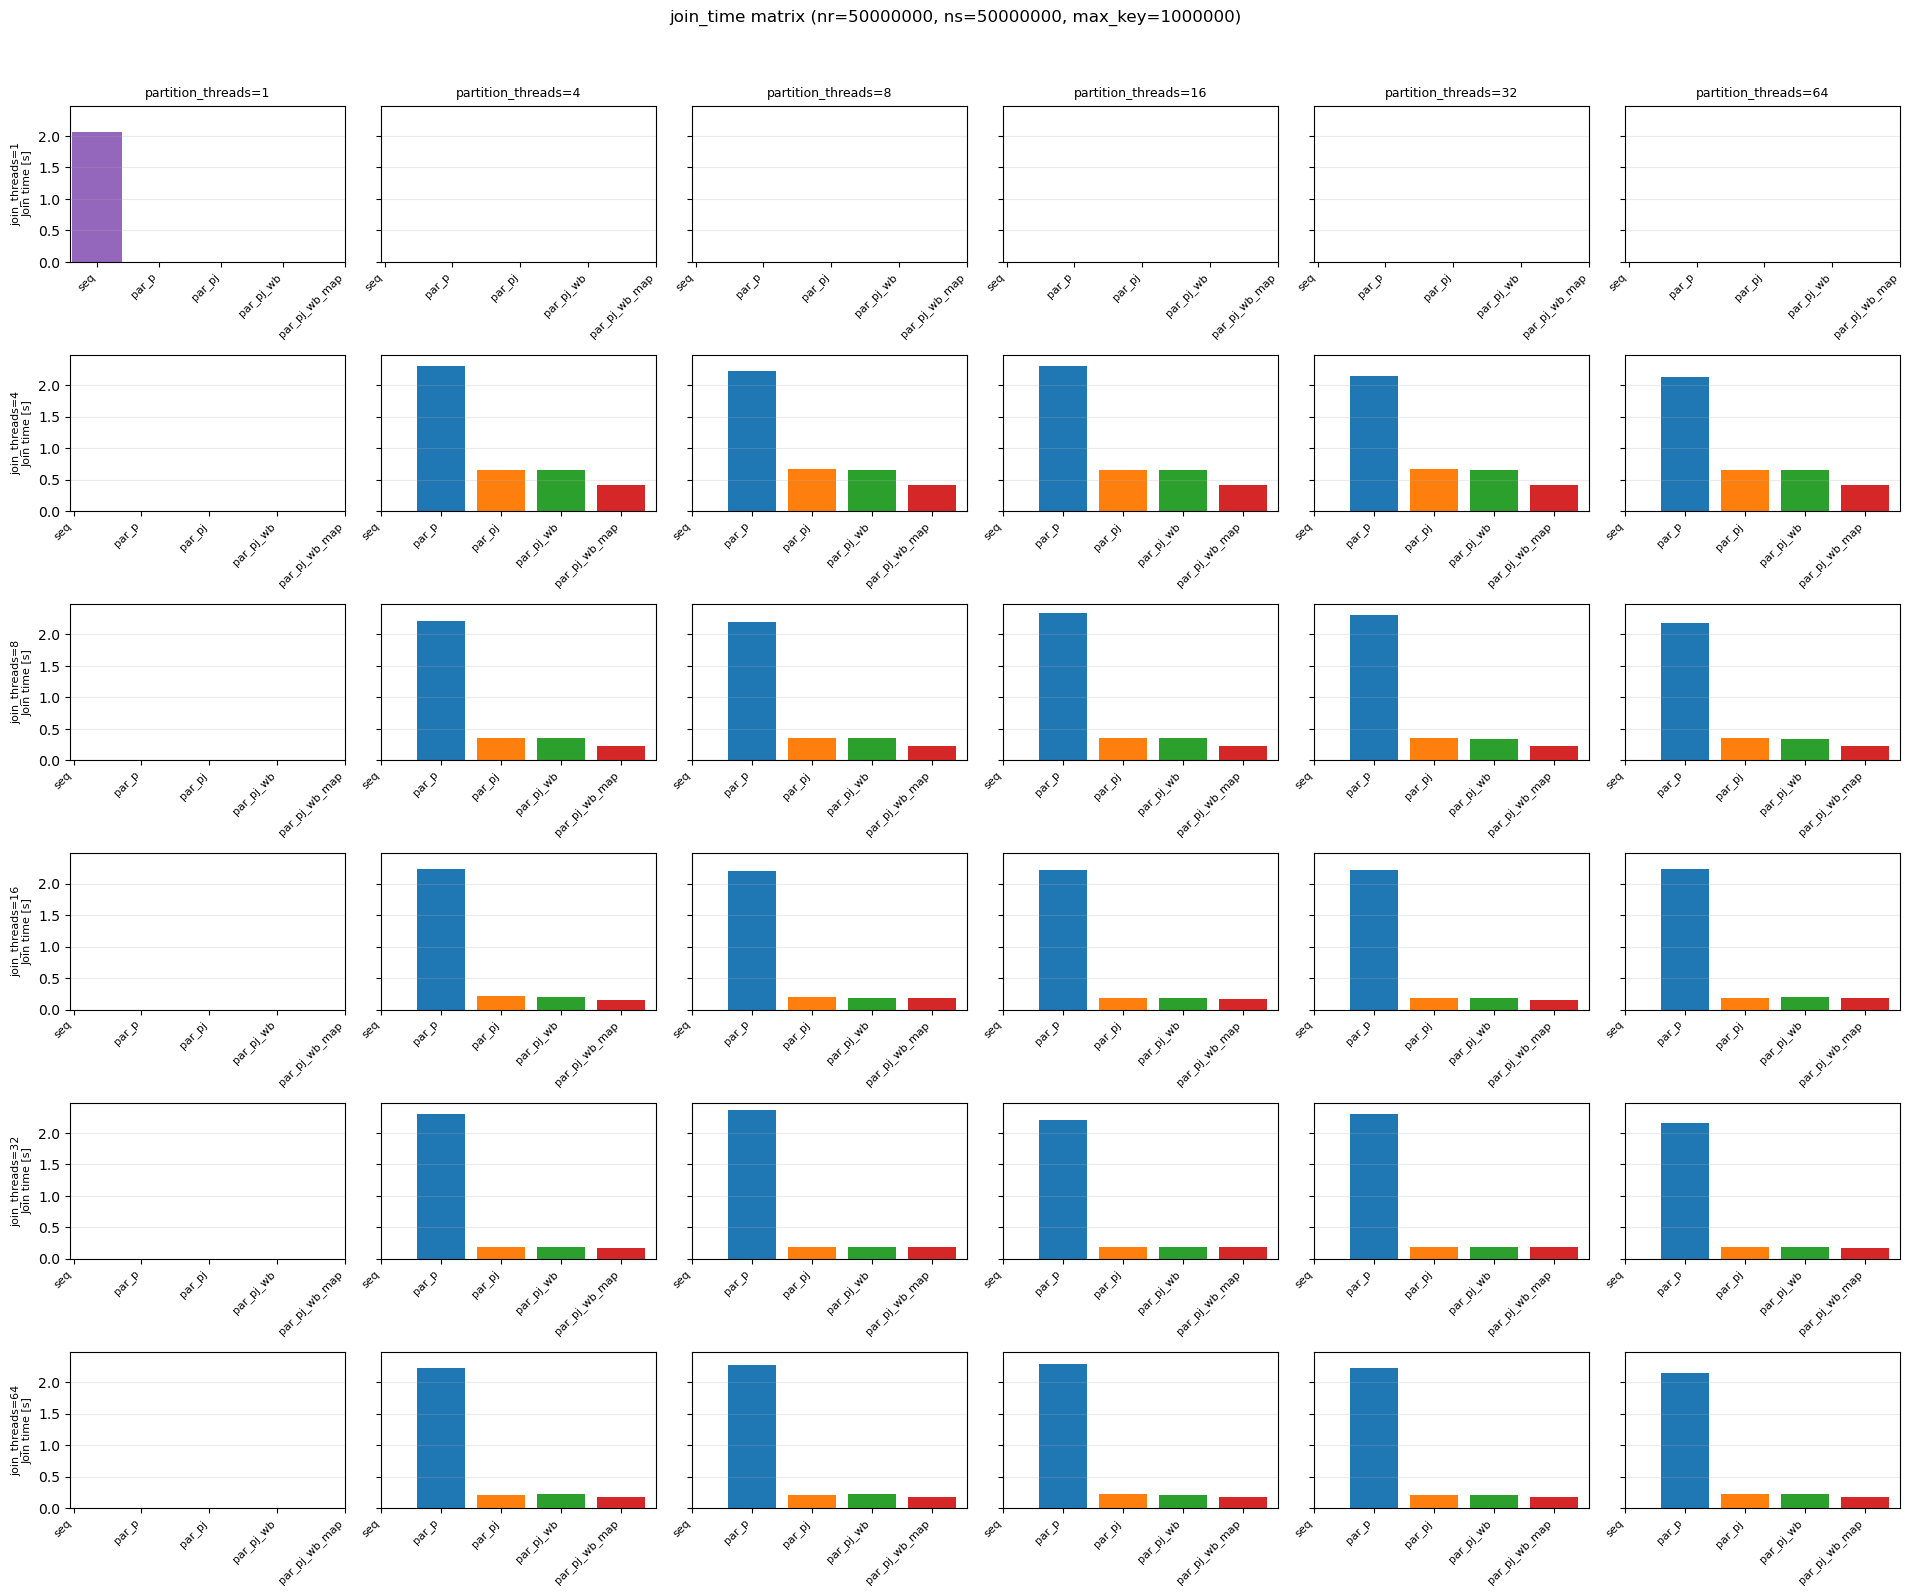

In [60]:
global_join_time_ymax = stable_avg_df["join_time"].max()
plot_thread_matrix(
    stable_avg_df,
    metric_col="join_time",
    y_label="Join time [s]",
    title_prefix="join_time",
    global_ymax=global_join_time_ymax,
)


# Join time standard deviation

[saved] img/004_std_join_time_by_max_key.png


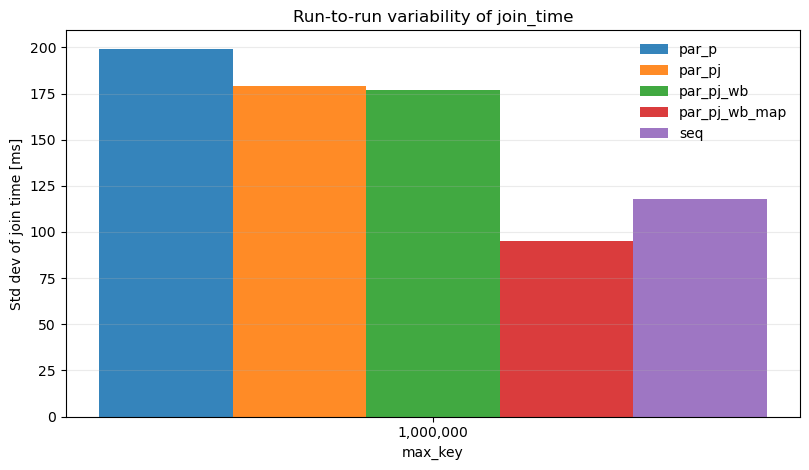

,max_key,exec_type,std_join_time,std_ms
0,1000000,par_p,0.199267,199.266931
1,1000000,par_pj,0.179227,179.226860
2,1000000,par_pj_wb,0.177087,177.086982
3,1000000,par_pj_wb_map,0.095286,95.286386
4,1000000,seq,0.117815,117.814522


In [61]:
std_df = (
    df.groupby(["max_key", "exec_type"], as_index=False)
    .agg(std_join_time=("join_time", "std"))
)
std_df["std_ms"] = std_df["std_join_time"] * 1e3

max_key_values = sorted(std_df["max_key"].dropna().unique())
exec_types = sorted(std_df["exec_type"].dropna().unique())

x_positions = list(range(len(max_key_values)))
bar_width = 0.8 / len(exec_types) if exec_types else 0.8

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for idx, exec_type in enumerate(exec_types):
    heights = []
    for max_key in max_key_values:
        sub = std_df[(std_df["max_key"] == max_key) & (std_df["exec_type"] == exec_type)]
        heights.append(float(sub["std_ms"].iloc[0]) if not sub.empty else float("nan"))

    offsets = [
        x + (idx - (len(exec_types) - 1) / 2) * bar_width
        for x in x_positions
    ]
    ax.bar(
        offsets,
        heights,
        width=bar_width,
        label=exec_type,
        color=exec_type_colors.get(exec_type, "tab:gray"),
        alpha=0.9,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels([f"{int(v):,}" for v in max_key_values])
ax.set_xlabel("max_key")
ax.set_ylabel("Std dev of join time [ms]")
ax.set_title("Run-to-run variability of join_time")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
show_and_save(fig, "std_join_time_by_max_key")

std_df.sort_values(["max_key", "exec_type"]).reset_index(drop=True)


# Speedup (total throughput)

In [62]:
baseline_exec_type = "seq"

baseline_df = (
    stable_avg_df[stable_avg_df["exec_type"] == baseline_exec_type][
        ["nr", "ns", "max_key", "total_throughput"]
    ]
    .groupby(["nr", "ns", "max_key"], as_index=False)
    .agg(baseline_total_throughput=("total_throughput", "mean"))
)

if baseline_df.empty:
    raise ValueError("No seq baseline available for speedup computation")

speedup_avg_df = stable_avg_df.merge(
    baseline_df,
    on=["nr", "ns", "max_key"],
    how="left",
)

speedup_avg_df["speedup_total_throughput"] = (
    speedup_avg_df["total_throughput"] / speedup_avg_df["baseline_total_throughput"]
)
speedup_avg_df.loc[speedup_avg_df["baseline_total_throughput"] <= 0, "speedup_total_throughput"] = float("nan")

speedup_avg_df.head(10)


,exec_type,nr,ns,max_key,partition_threads,join_threads,checksum1,checksum2,join_count,partition_time,join_time,time_sec,partition_throughput,join_throughput,total_throughput,baseline_total_throughput,speedup_total_throughput
0,par_p,50000000,50000000,1000000,4,4,6185417096973469475,16931092769743058723,2499986166,0.918371,2.296605,3.217214,1.088893e+08,4.391655e+07,3.121363e+07,2.492717e+07,1.252193
1,par_p,50000000,50000000,1000000,4,8,6185417096973469475,16931092769743058723,2499986166,0.928452,2.215488,3.146184,1.077168e+08,4.550518e+07,3.191238e+07,2.492717e+07,1.280225
2,par_p,50000000,50000000,1000000,4,16,6185417096973469475,16931092769743058723,2499986166,0.920281,2.236525,3.159045,1.086645e+08,4.510712e+07,3.179849e+07,2.492717e+07,1.275656
3,par_p,50000000,50000000,1000000,4,32,6185417096973469475,16931092769743058723,2499986166,0.925180,2.300421,3.227885,1.080976e+08,4.381352e+07,3.110676e+07,2.492717e+07,1.247906
4,par_p,50000000,50000000,1000000,4,64,6185417096973469475,16931092769743058723,2499986166,0.918467,2.219970,3.140709,1.088798e+08,4.538073e+07,3.196101e+07,2.492717e+07,1.282176
5,par_p,50000000,50000000,1000000,8,4,6185417096973469475,16931092769743058723,2499986166,0.600664,2.226311,2.829213,1.664839e+08,4.520071e+07,3.548525e+07,2.492717e+07,1.423557
6,par_p,50000000,50000000,1000000,8,8,6185417096973469475,16931092769743058723,2499986166,0.599982,2.199622,2.802032,1.666785e+08,4.580279e+07,3.585358e+07,2.492717e+07,1.438334
7,par_p,50000000,50000000,1000000,8,16,6185417096973469475,16931092769743058723,2499986166,0.598968,2.195755,2.797002,1.669571e+08,4.592830e+07,3.594132e+07,2.492717e+07,1.441854
8,par_p,50000000,50000000,1000000,8,32,6185417096973469475,16931092769743058723,2499986166,0.599751,2.363519,2.965585,1.667364e+08,4.250353e+07,3.381657e+07,2.492717e+07,1.356615
9,par_p,50000000,50000000,1000000,8,64,6185417096973469475,16931092769743058723,2499986166,0.597889,2.275230,2.875373,1.672577e+08,4.429260e+07,3.494304e+07,2.492717e+07,1.401805


[saved] img/005_speedup_total_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


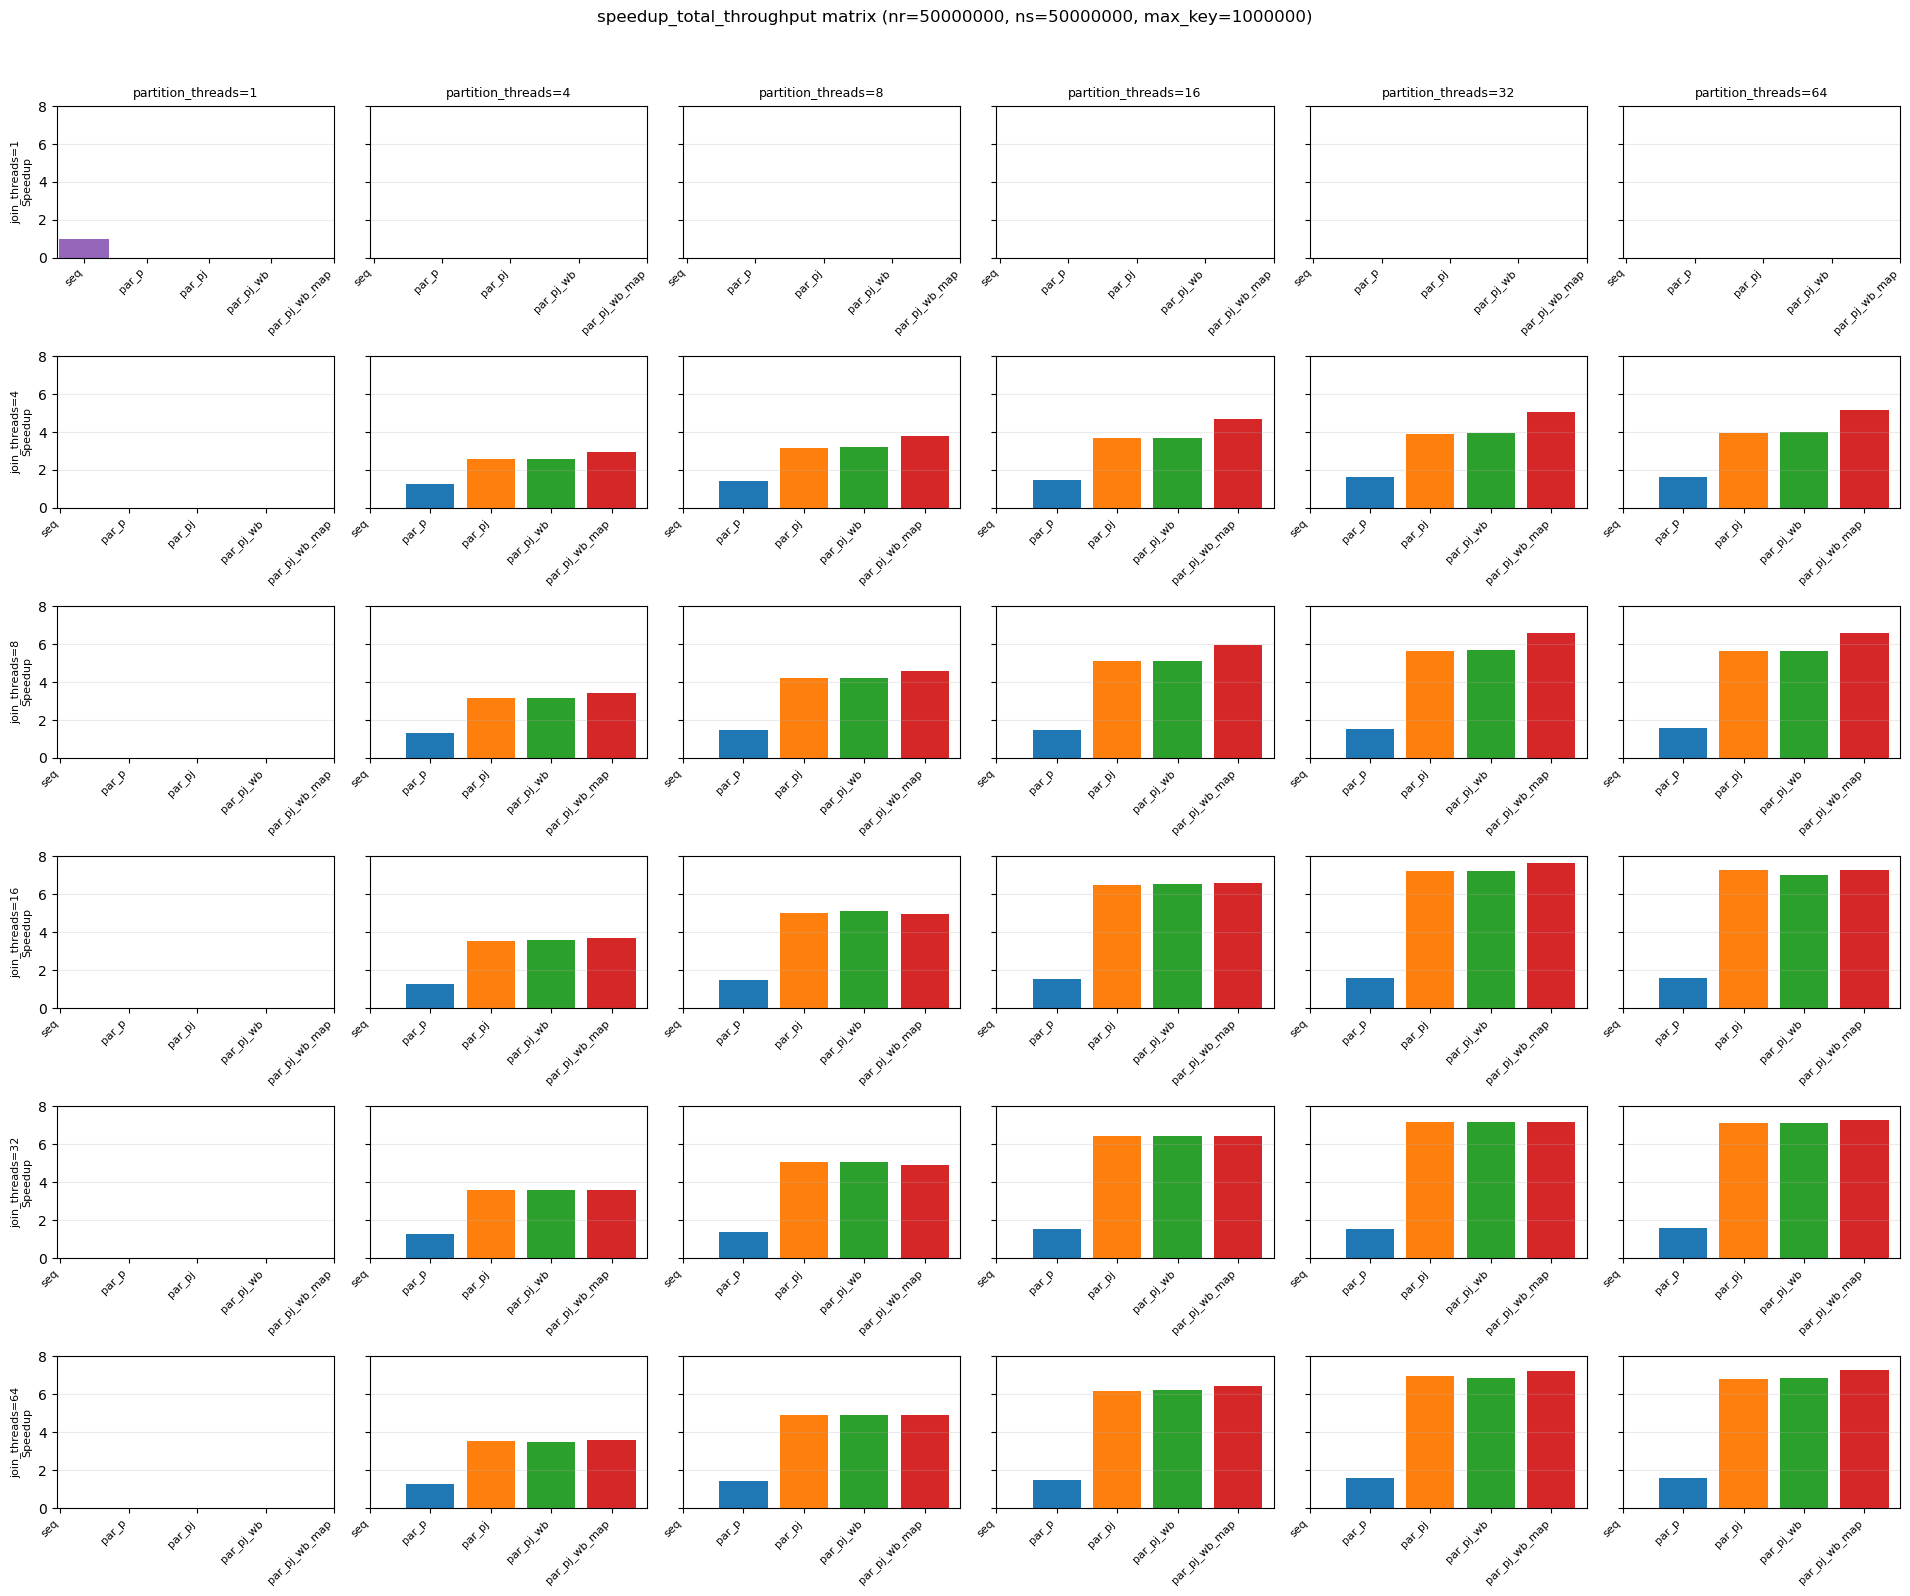

In [63]:
global_speedup_ymax = speedup_avg_df["speedup_total_throughput"].max()
plot_thread_matrix(
    speedup_avg_df,
    metric_col="speedup_total_throughput",
    y_label="Speedup",
    title_prefix="speedup_total_throughput",
    global_ymax=global_speedup_ymax,
)


# Throughput

[saved] img/006_partition_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


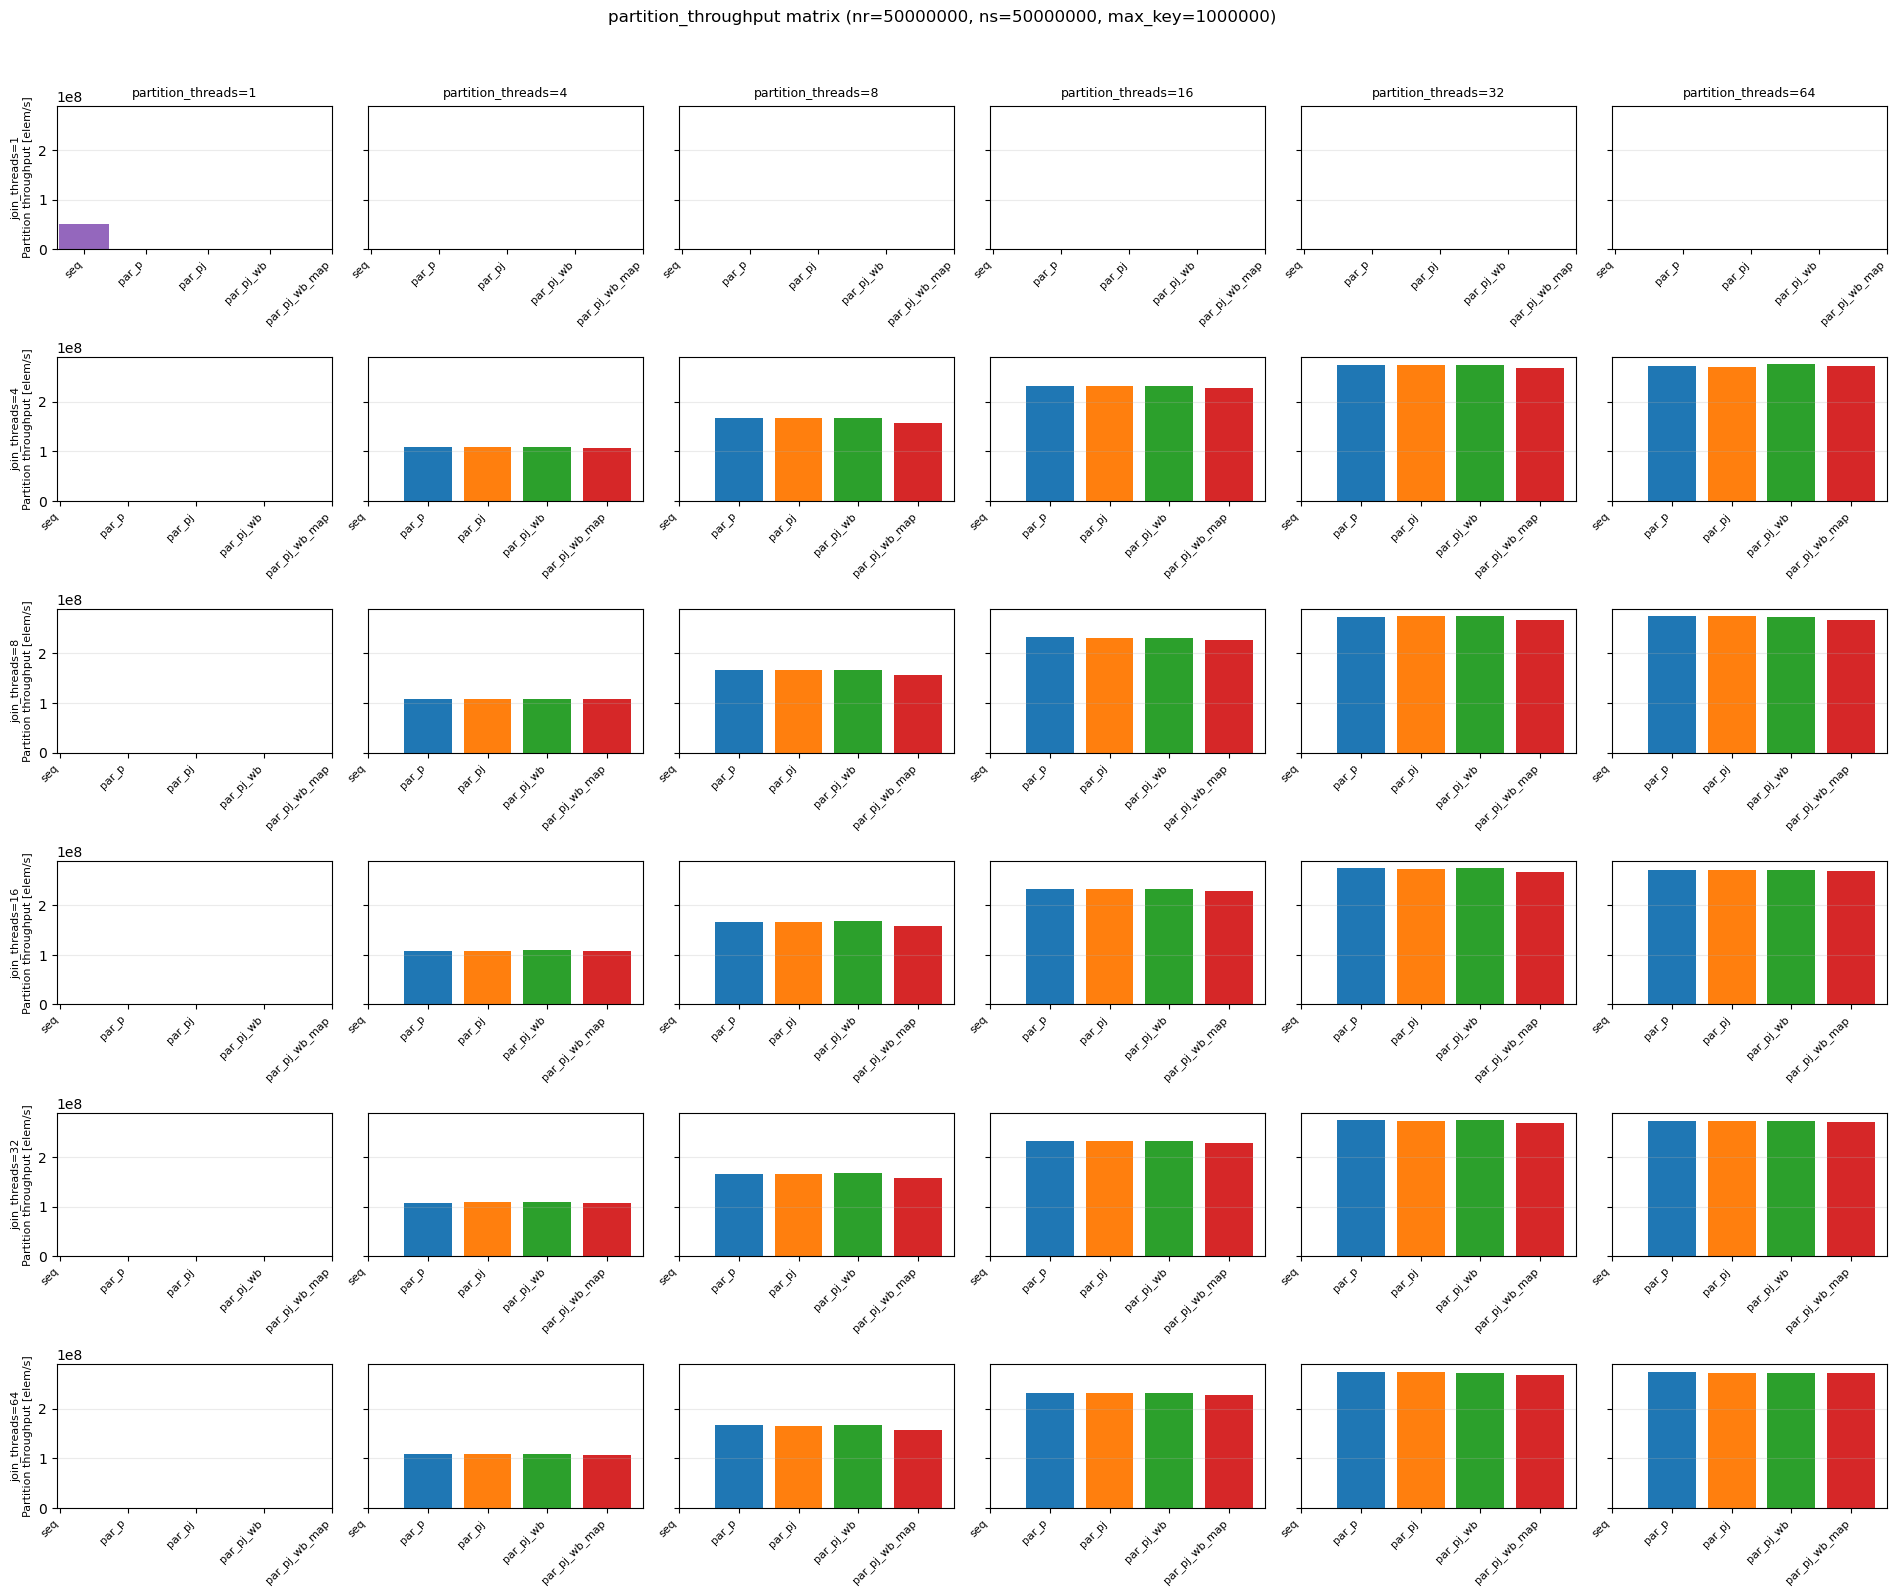

[saved] img/007_join_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


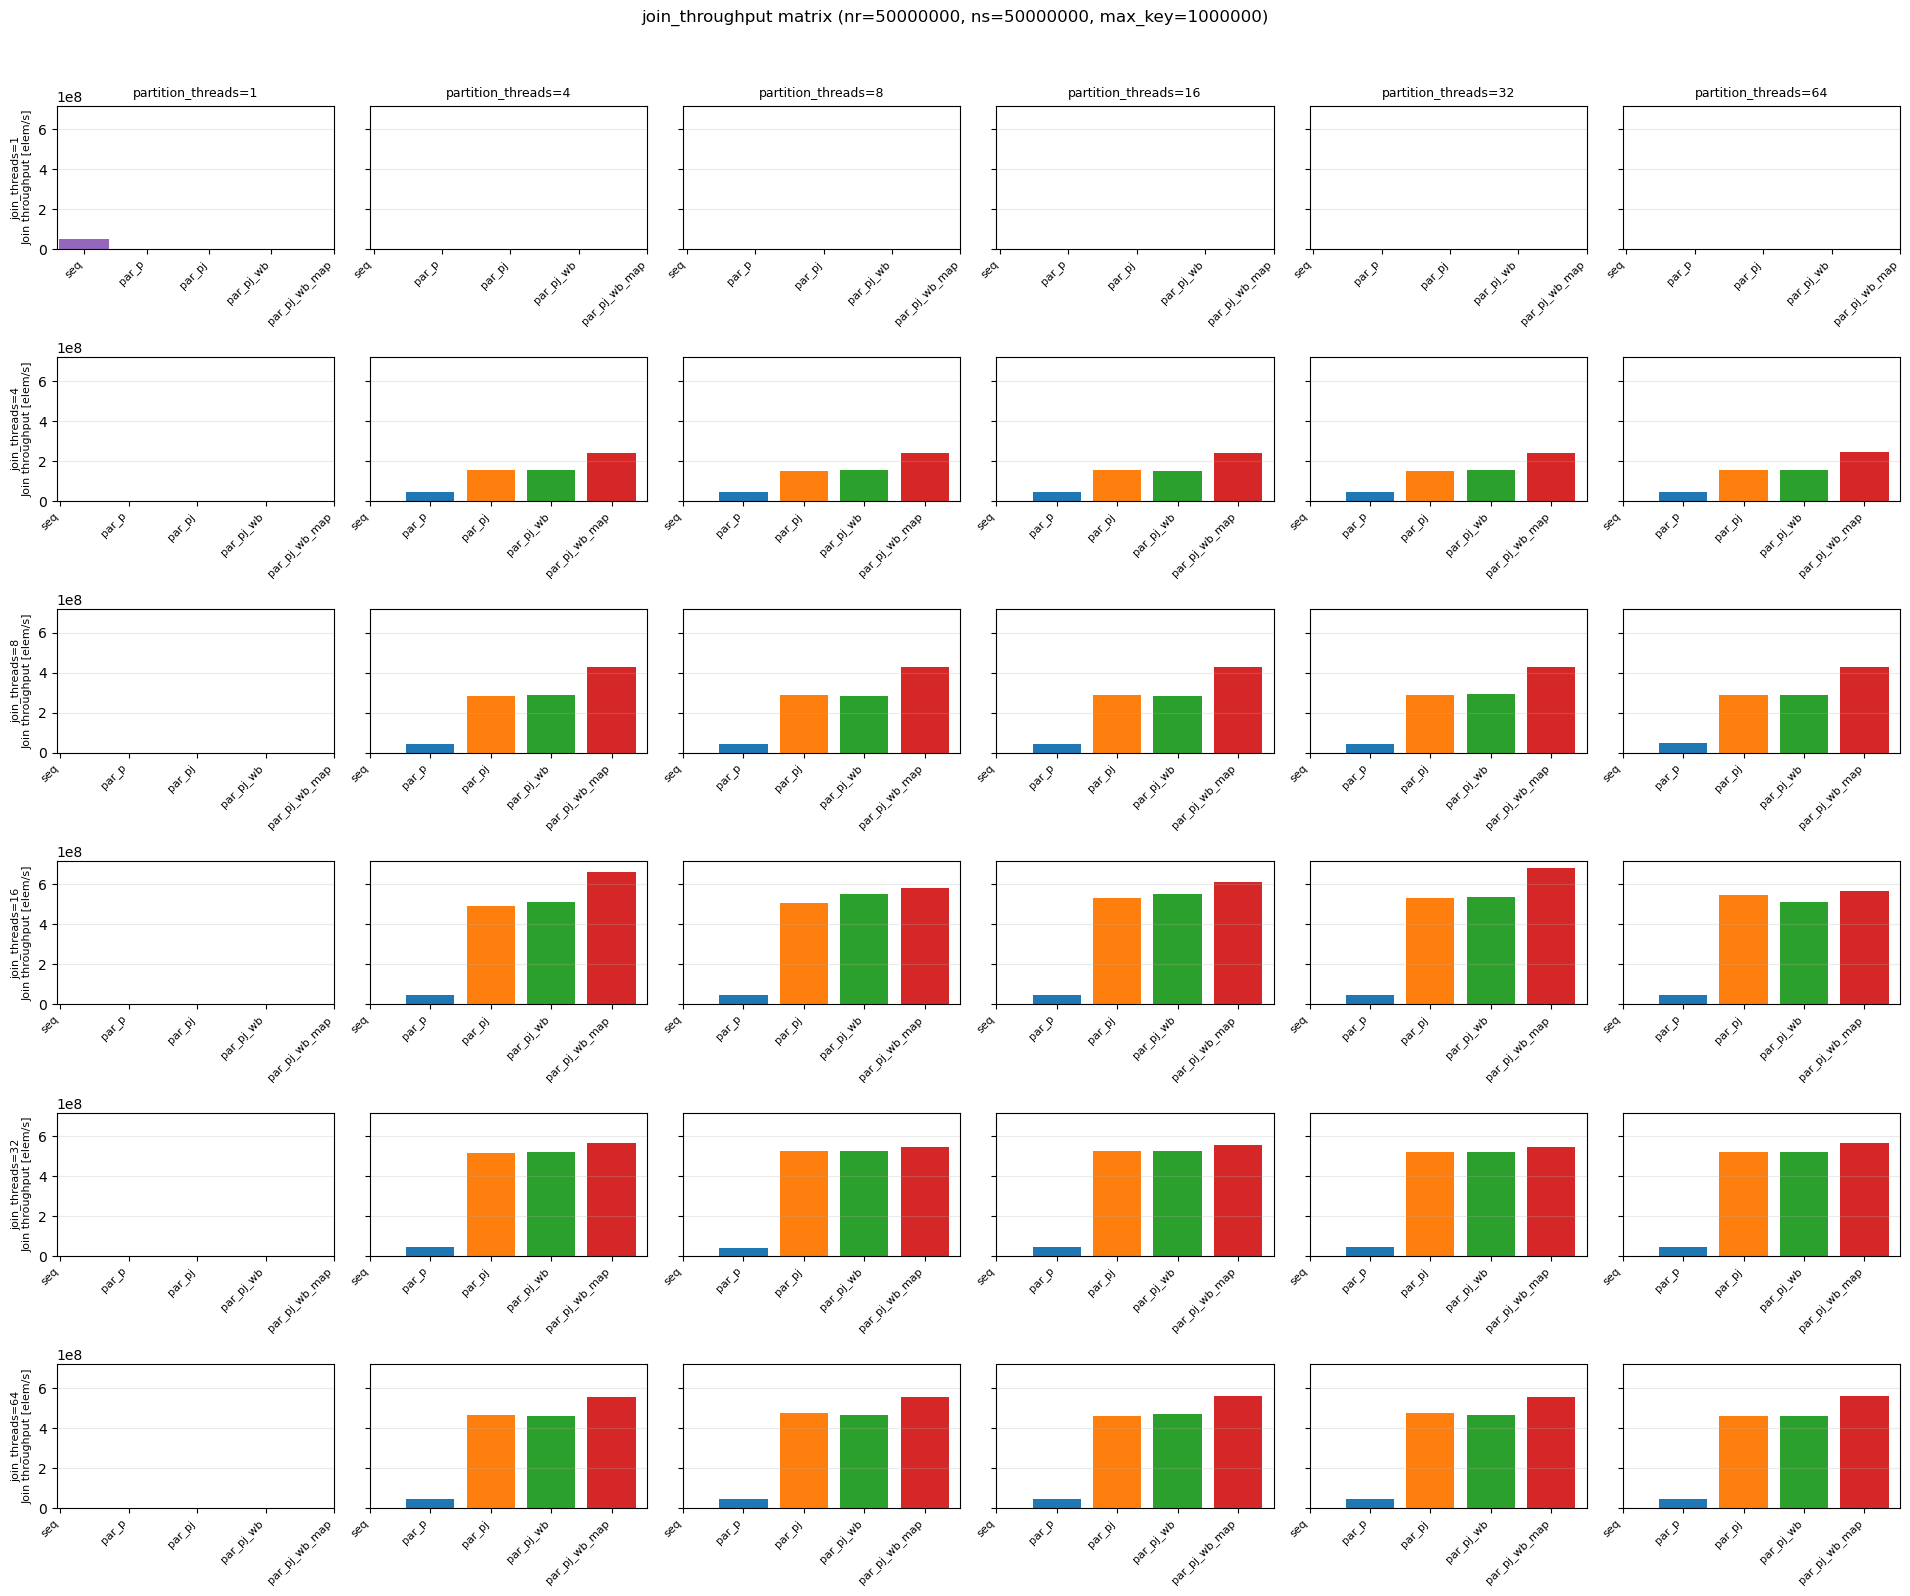

[saved] img/008_total_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


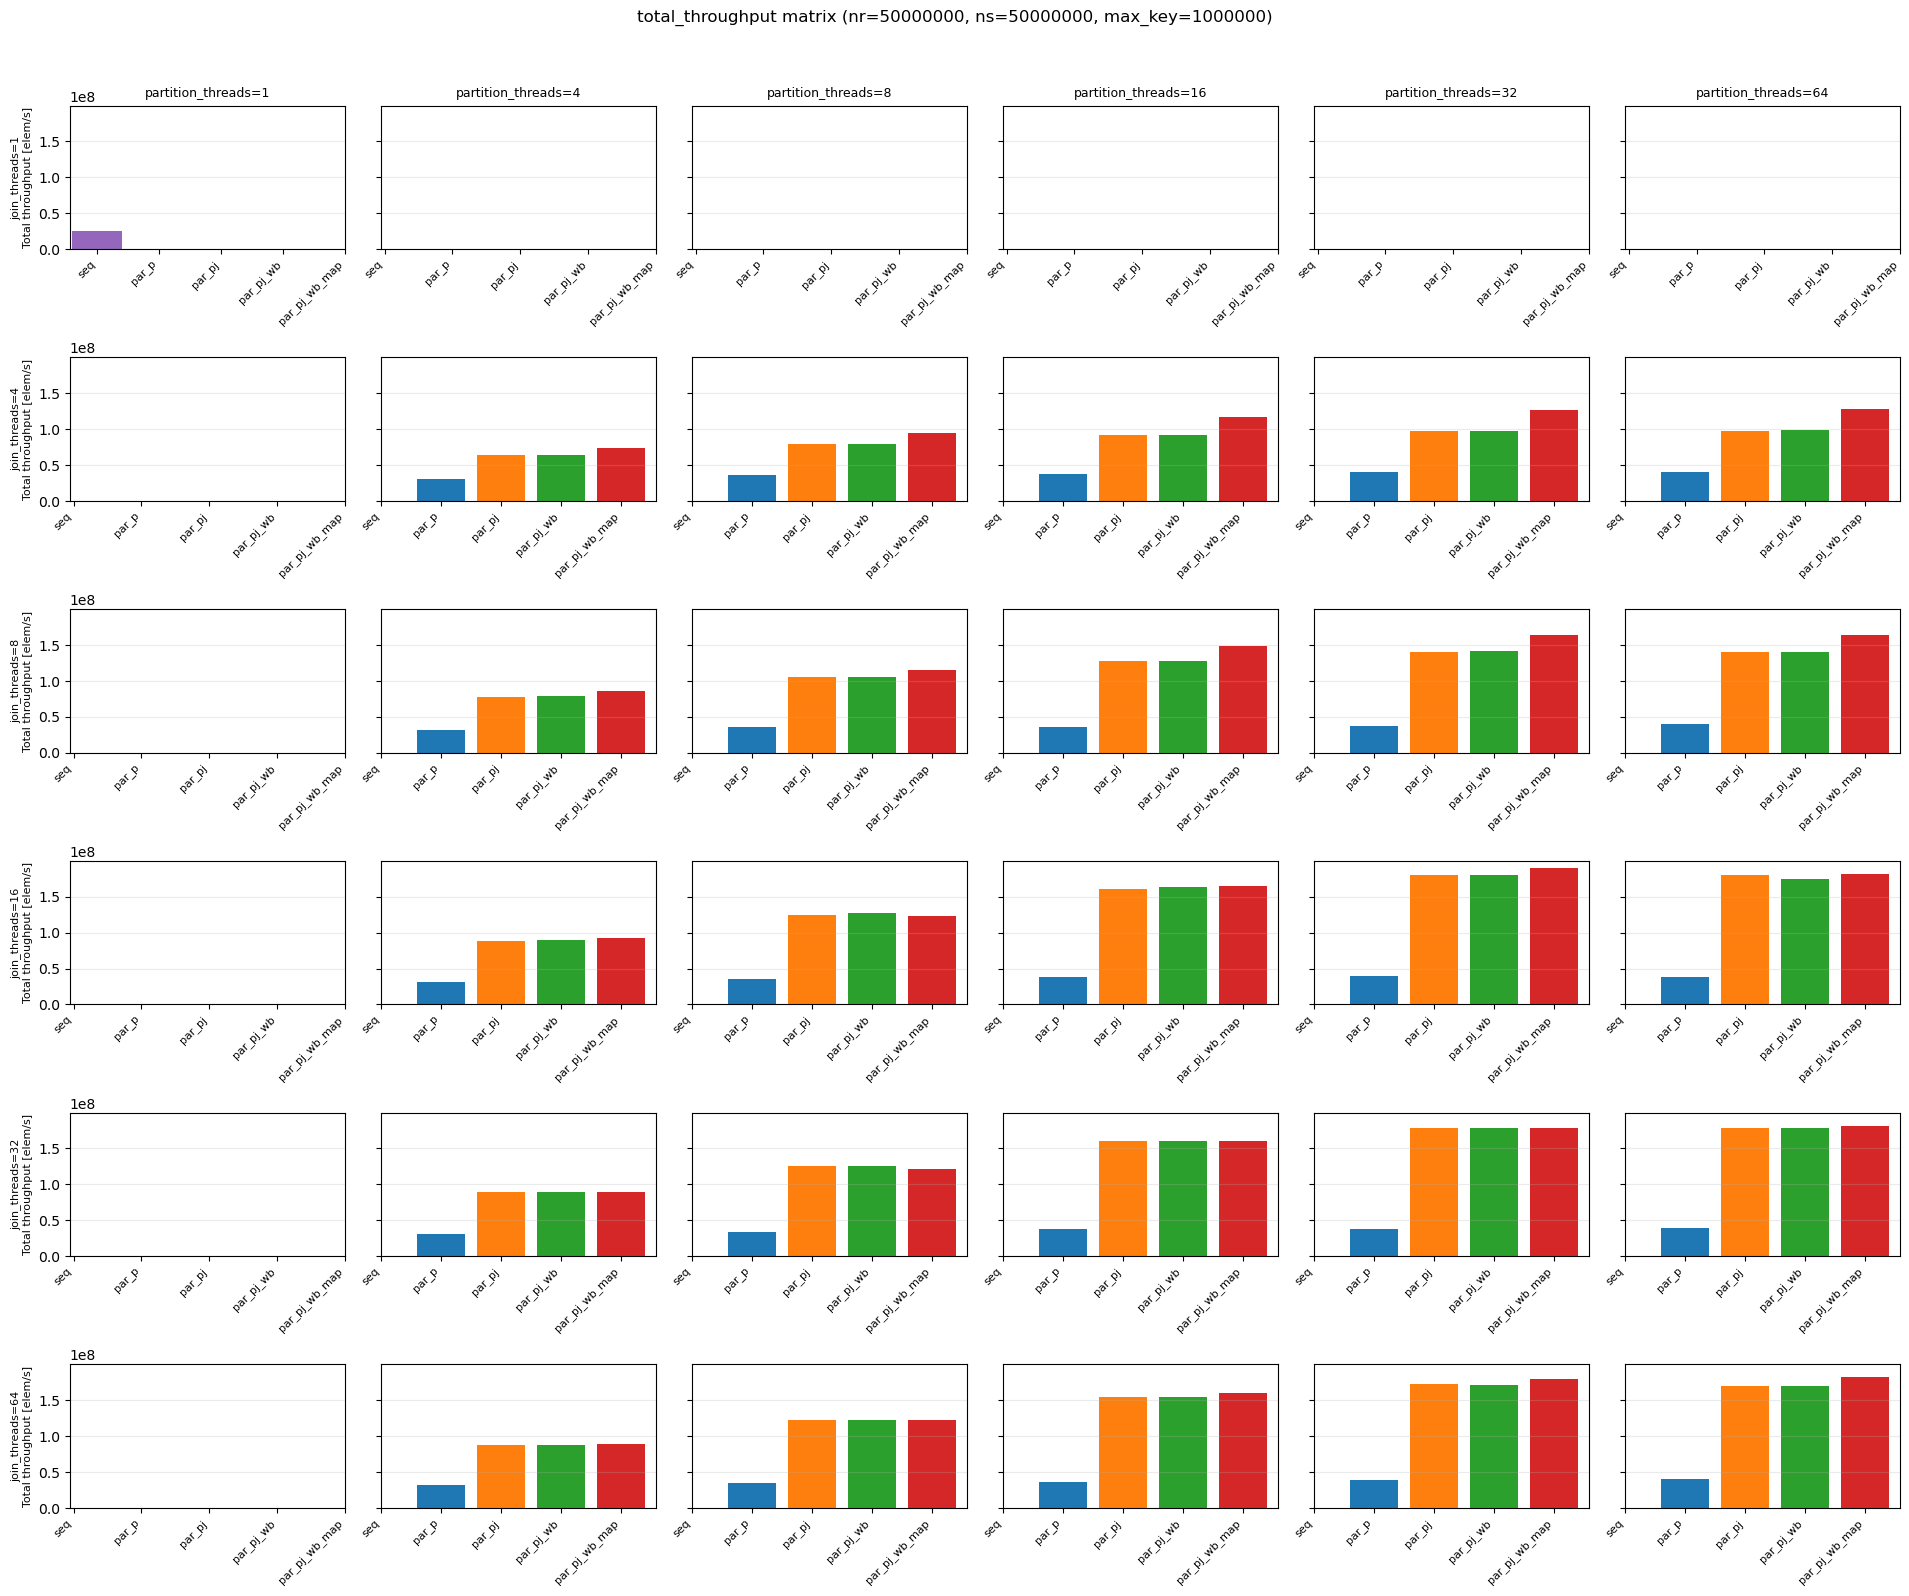

In [64]:
throughput_metrics = [
    ("partition_throughput", "Partition throughput [elem/s]"),
    ("join_throughput", "Join throughput [elem/s]"),
    ("total_throughput", "Total throughput [elem/s]"),
]

for metric_col, ylabel in throughput_metrics:
    if metric_col not in stable_avg_df.columns:
        continue

    global_metric_ymax = stable_avg_df[metric_col].max()
    plot_thread_matrix(
        stable_avg_df,
        metric_col=metric_col,
        y_label=ylabel,
        title_prefix=metric_col,
        global_ymax=global_metric_ymax,
    )
